# Análise Detalhada - Table01 (Centralidade 0-5%)
## Distribuição de pT de Píons em Colisões Pb-Pb

Este notebook analisa o arquivo Table01.csv com dados do experimento Atlas ins1759506 para a centralidade 0-5%. Examinaremos todas as informações disponíveis: valores medidos, erros estatísticos, erros sistemáticos correlacionados e não correlacionados.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuração visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")     

# Parâmetros de exibição
FIGURE_SIZE = (14, 9)
DPI = 300
OUTPUT_FORMAT = 'png'

# Diretório de dados
DATA_DIR = Path("/Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506")
OUTPUT_DIR = Path("/Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Diretório de dados: {DATA_DIR}")
print(f"Diretório de saída: {OUTPUT_DIR}")

Diretório de dados: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Atlas-ins1759506
Diretório de saída: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots


## 1. Leitura e Extração de Metadados - Table01.csv

In [13]:
csv_file = DATA_DIR / "Table01.csv"

# Extrair metadados do arquivo
metadata = {}
with open(csv_file, 'r') as f:
    for line in f:
        if line.startswith('#: '):
            # Extrair informações dos comentários
            if 'CENTRALITY' in line:
                parts = line.split(',')
                if len(parts) >= 4:
                    metadata['centrality'] = parts[3].strip()
            elif 'description:' in line:
                metadata['description'] = line.split('description:')[1].strip()
            elif 'keyword reactions:' in line:
                metadata['reactions'] = line.split('keyword reactions:')[1].strip()
            elif 'keyword observables:' in line:
                metadata['observables'] = line.split('keyword observables:')[1].strip()
            elif 'cmenergies' in line:
                parts = line.split(',')
                if len(parts) >= 4:
                    metadata['energy'] = parts[3].strip()
            elif 'YRAP' in line:
                parts = line.split(',')
                if len(parts) >= 4:
                    metadata['rapidity'] = parts[3].strip()
        elif not line.startswith('#'):
            break

# Contar linhas de cabeçalho (começam com #)
header_lines = 0
with open(csv_file, 'r') as f:
    for line in f:
        if line.startswith('#'):
            header_lines += 1
        else:
            break

# Ler dados
df = pd.read_csv(csv_file, skiprows=header_lines, skipinitialspace=True)

# Padronizar nomes das colunas
df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

# Converter TODAS as colunas para numérico
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("=" * 100)
print("METADADOS - Table01.csv")
print("=" * 100)
for key, value in metadata.items():
    print(f"{key:20s}: {value}")

print("\n" + "=" * 100)
print("INFORMAÇÕES DO DATAFRAME")
print("=" * 100)
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")
print(f"\nColunas:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n\nPrimeiras 5 linhas:")
print(df.head())

METADADOS - Table01.csv
description         : $p_{T}$-distributions of pions ($\pi^{+}+\pi^{-}$) measured in Pb-Pb collisions at $\sqrt{s_{NN}}$ = 5.02 TeV.
reactions           : PB PB --> PI+ X | PB PB --> PI- X
observables         : DN/DPT
centrality          : 0.0-5.0
rapidity            : -0.5-0.5

INFORMAÇÕES DO DATAFRAME
Total de linhas: 625
Total de colunas: 10

Colunas:
   1. $p_{t}$_[$gev/c$]
   2. $p_{t}$_[$gev/c$]_low
   3. $p_{t}$_[$gev/c$]_high
   4. (1/nev)*d2(n)/dpt/dyrap_[$(gev/c)^{-1}$]
   5. stat._+
   6. stat._-
   7. syst._+
   8. syst._-
   9. syst._uncorr._+
  10. syst._uncorr._-


Primeiras 5 linhas:
   $p_{t}$_[$gev/c$]  $p_{t}$_[$gev/c$]_low  $p_{t}$_[$gev/c$]_high  \
0               0.11                   0.10                    0.12   
1               0.13                   0.12                    0.14   
2               0.15                   0.14                    0.16   
3               0.17                   0.16                    0.18   
4             

## 2. Gráfico Principal - Distribuição pT com Erros Totais

Coluna pT: $p_{t}$_[$gev/c$]
Coluna valor: (1/nev)*d2(n)/dpt/dyrap_[$(gev/c)^{-1}$]
Colunas de erro encontradas:
  - Erro estatístico (+/-): stat._+, stat._-
  - Erro sistemático (+/-): syst._+, syst._-
  - Erro sistemático não correlacionado (+/-): syst._uncorr._+, syst._uncorr._-


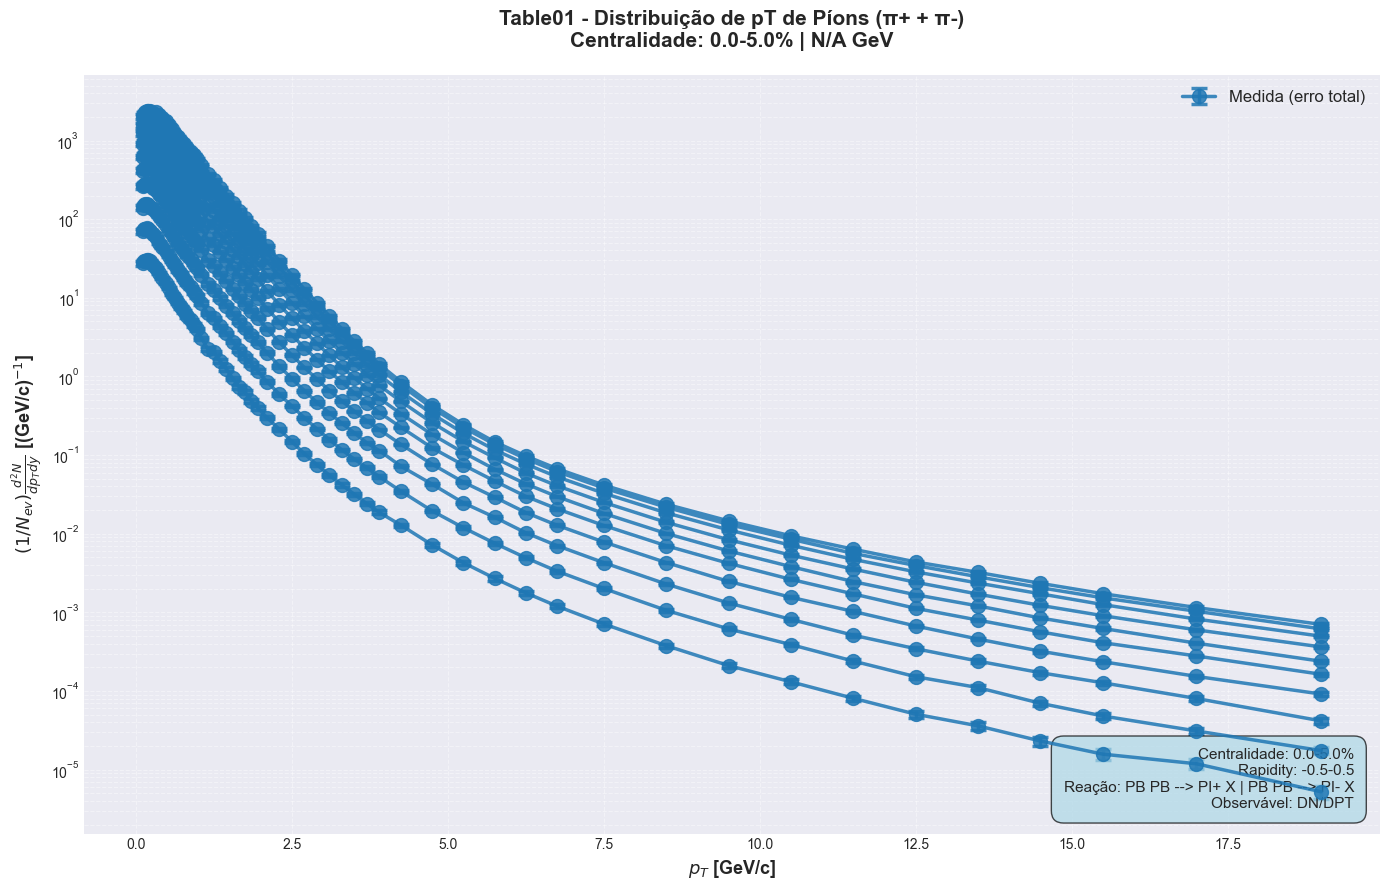


✓ Gráfico salvo em: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots/Table01_centrality_0-5_main.png


In [14]:
# Identificar colunas de pT e valor
pt_col = df.columns[0]  # pT central
value_col = df.columns[3]  # Valor medido

# Identificar colunas de erro
stat_plus_col = 'stat._+'
stat_minus_col = 'stat._-'
syst_plus_col = 'syst._+'
syst_minus_col = 'syst._-'
syst_uncorr_plus_col = 'syst._uncorr._+'
syst_uncorr_minus_col = 'syst._uncorr._-'

print(f"Coluna pT: {pt_col}")
print(f"Coluna valor: {value_col}")
print(f"Colunas de erro encontradas:")
print(f"  - Erro estatístico (+/-): {stat_plus_col}, {stat_minus_col}")
print(f"  - Erro sistemático (+/-): {syst_plus_col}, {syst_minus_col}")
print(f"  - Erro sistemático não correlacionado (+/-): {syst_uncorr_plus_col}, {syst_uncorr_minus_col}")

# Calcular erro total (estatístico + sistemático em quadratura)
error_total_plus = np.sqrt(
    df[stat_plus_col]**2 + 
    df[syst_plus_col]**2
)
error_total_minus = np.sqrt(
    df[stat_minus_col]**2 + 
    df[syst_minus_col]**2
)

# Criar figura principal
fig, ax = plt.subplots(figsize=FIGURE_SIZE)

# Plotar dados com barras de erro totais
ax.errorbar(df[pt_col], df[value_col],
            yerr=[error_total_minus, error_total_plus],
            fmt='o-', markersize=10, linewidth=2.5,
            capsize=6, capthick=2.5, elinewidth=2.5,
            color='#1f77b4', alpha=0.85,
            label='Medida (erro total)', zorder=3)

# Customização
centrality_str = metadata.get('centrality', 'Desconhecida')
title = f"Table01 - Distribuição de pT de Píons (π+ + π-)\nCentralidade: {centrality_str}% | {metadata.get('energy', 'N/A')} GeV"
ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel(r"$p_T$ [GeV/c]", fontsize=13, fontweight='bold')
ylabel = r"$(1/N_{ev})\frac{d^2N}{dp_T dy}$ [(GeV/c)$^{-1}$]"
ax.set_ylabel(ylabel, fontsize=13, fontweight='bold')

ax.grid(True, which='both', alpha=0.4, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_yscale('log')

# Legenda com informações
legend_text = f"Centralidade: {centrality_str}%\n"
legend_text += f"Rapidity: {metadata.get('rapidity', 'N/A')}\n"
legend_text += f"Reação: {metadata.get('reactions', 'N/A')}\n"
legend_text += f"Observável: {metadata.get('observables', 'N/A')}"

ax.text(0.98, 0.03, legend_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, pad=0.8))

ax.legend(loc='upper right', fontsize=12, framealpha=0.95)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Table01_centrality_0-5_main.png", dpi=DPI, bbox_inches='tight')
plt.show()

print(f"\n✓ Gráfico salvo em: {OUTPUT_DIR / 'Table01_centrality_0-5_main.png'}")

## 3. Decomposição de Erros - Componentes Individuais

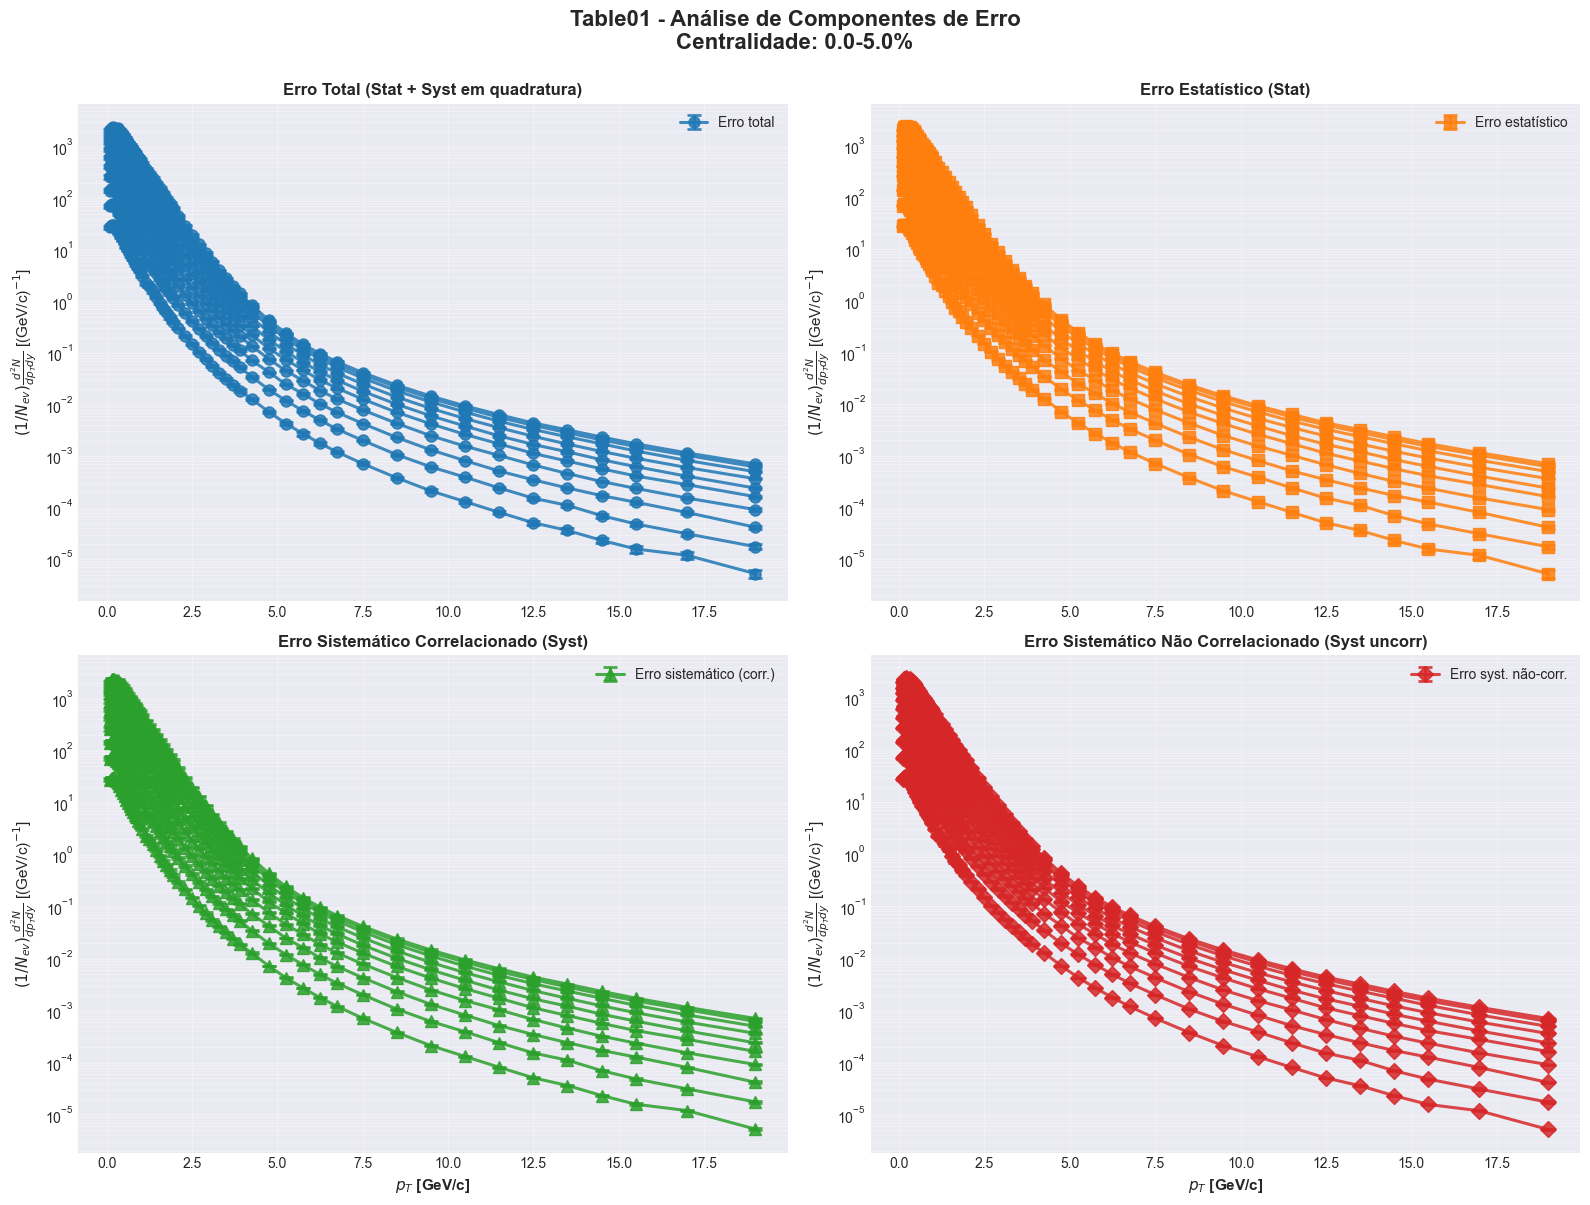

✓ Gráfico de decomposição salvo em: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots/Table01_centrality_0-5_error_decomposition.png


In [16]:
# Criar figura com múltiplos subplots mostrando cada tipo de erro
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Table01 - Análise de Componentes de Erro\nCentralidade: {centrality_str}%", 
             fontsize=16, fontweight='bold', y=1.00)

# 1. Erro Total
ax = axes[0, 0]
ax.errorbar(df[pt_col], df[value_col],
            yerr=[error_total_minus, error_total_plus],
            fmt='o-', markersize=8, linewidth=2.2,
            capsize=5, capthick=2, elinewidth=2,
            color='#1f77b4', alpha=0.85, label='Erro total')
ax.set_title('Erro Total (Stat + Syst em quadratura)', fontsize=12, fontweight='bold')
ax.set_ylabel(r"$(1/N_{ev})\frac{d^2N}{dp_T dy}$ [(GeV/c)$^{-1}$]", fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_yscale('log')
ax.legend()

# 2. Erro Estatístico (tomar valor absoluto)
ax = axes[0, 1]
ax.errorbar(df[pt_col], df[value_col],
            yerr=[np.abs(df[stat_minus_col]), np.abs(df[stat_plus_col])],
            fmt='s-', markersize=8, linewidth=2.2,
            capsize=5, capthick=2, elinewidth=2,
            color='#ff7f0e', alpha=0.85, label='Erro estatístico')
ax.set_title('Erro Estatístico (Stat)', fontsize=12, fontweight='bold')
ax.set_ylabel(r"$(1/N_{ev})\frac{d^2N}{dp_T dy}$ [(GeV/c)$^{-1}$]", fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_yscale('log')
ax.legend()

# 3. Erro Sistemático (Correlacionado)
ax = axes[1, 0]
ax.errorbar(df[pt_col], df[value_col],
            yerr=[np.abs(df[syst_minus_col]), np.abs(df[syst_plus_col])],
            fmt='^-', markersize=8, linewidth=2.2,
            capsize=5, capthick=2, elinewidth=2,
            color='#2ca02c', alpha=0.85, label='Erro sistemático (corr.)')
ax.set_title('Erro Sistemático Correlacionado (Syst)', fontsize=12, fontweight='bold')
ax.set_xlabel(r"$p_T$ [GeV/c]", fontsize=11, fontweight='bold')
ax.set_ylabel(r"$(1/N_{ev})\frac{d^2N}{dp_T dy}$ [(GeV/c)$^{-1}$]", fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_yscale('log')
ax.legend()

# 4. Erro Sistemático Não Correlacionado
ax = axes[1, 1]
ax.errorbar(df[pt_col], df[value_col],
            yerr=[np.abs(df[syst_uncorr_minus_col]), np.abs(df[syst_uncorr_plus_col])],
            fmt='D-', markersize=8, linewidth=2.2,
            capsize=5, capthick=2, elinewidth=2,
            color='#d62728', alpha=0.85, label='Erro syst. não-corr.')
ax.set_title('Erro Sistemático Não Correlacionado (Syst uncorr)', fontsize=12, fontweight='bold')
ax.set_xlabel(r"$p_T$ [GeV/c]", fontsize=11, fontweight='bold')
ax.set_ylabel(r"$(1/N_{ev})\frac{d^2N}{dp_T dy}$ [(GeV/c)$^{-1}$]", fontsize=11)
ax.grid(True, which='both', alpha=0.3)
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Table01_centrality_0-5_error_decomposition.png", dpi=DPI, bbox_inches='tight')
plt.show()

print(f"✓ Gráfico de decomposição salvo em: {OUTPUT_DIR / 'Table01_centrality_0-5_error_decomposition.png'}")

## 4. Análise Estatística e Resumo dos Dados

In [18]:
# Análise estatística dos erros
print("=" * 100)
print("ANÁLISE ESTATÍSTICA DOS ERROS - Table01")
print("=" * 100)

# Estatísticas do erro total
error_total_avg_plus = error_total_plus.mean()
error_total_avg_minus = error_total_minus.mean()
error_total_rel_plus = (error_total_plus / df[value_col] * 100).mean()
error_total_rel_minus = (error_total_minus / df[value_col] * 100).mean()

print(f"\n### ERRO TOTAL (Stat + Syst):")
print(f"  Erro médio (+): {error_total_avg_plus:.2f} | Erro relativo médio: {error_total_rel_plus:.2f}%")
print(f"  Erro médio (-): {error_total_avg_minus:.2f} | Erro relativo médio: {error_total_rel_minus:.2f}%")

# Estatísticas do erro estatístico
stat_avg_plus = df[stat_plus_col].mean()
stat_avg_minus = df[stat_minus_col].mean()
stat_rel_plus = (df[stat_plus_col] / df[value_col] * 100).mean()
stat_rel_minus = (df[stat_minus_col] / df[value_col] * 100).mean()

print(f"\n### ERRO ESTATÍSTICO (Stat):")
print(f"  Erro médio (+): {stat_avg_plus:.2f} | Erro relativo médio: {stat_rel_plus:.2f}%")
print(f"  Erro médio (-): {stat_avg_minus:.2f} | Erro relativo médio: {stat_rel_minus:.2f}%")

# Estatísticas do erro sistemático (correlacionado)
syst_avg_plus = df[syst_plus_col].mean()
syst_avg_minus = df[syst_minus_col].mean()
syst_rel_plus = (df[syst_plus_col] / df[value_col] * 100).mean()
syst_rel_minus = (df[syst_minus_col] / df[value_col] * 100).mean()

print(f"\n### ERRO SISTEMÁTICO CORRELACIONADO (Syst):")
print(f"  Erro médio (+): {syst_avg_plus:.2f} | Erro relativo médio: {syst_rel_plus:.2f}%")
print(f"  Erro médio (-): {syst_avg_minus:.2f} | Erro relativo médio: {syst_rel_minus:.2f}%")

# Estatísticas do erro sistemático não correlacionado
syst_uncorr_avg_plus = df[syst_uncorr_plus_col].mean()
syst_uncorr_avg_minus = df[syst_uncorr_minus_col].mean()
syst_uncorr_rel_plus = (df[syst_uncorr_plus_col] / df[value_col] * 100).mean()
syst_uncorr_rel_minus = (df[syst_uncorr_minus_col] / df[value_col] * 100).mean()

print(f"\n### ERRO SISTEMÁTICO NÃO CORRELACIONADO (Syst uncorr):")
print(f"  Erro médio (+): {syst_uncorr_avg_plus:.2f} | Erro relativo médio: {syst_uncorr_rel_plus:.2f}%")
print(f"  Erro médio (-): {syst_uncorr_avg_minus:.2f} | Erro relativo médio: {syst_uncorr_rel_minus:.2f}%")

print("\n" + "=" * 100)
print("RESUMO DOS DADOS")
print("=" * 100)
print(f"Total de pontos de medida: {len(df)}")
print(f"Intervalo de pT: {df[pt_col].min():.3f} - {df[pt_col].max():.3f} GeV/c")
print(f"Intervalo de valores: {df[value_col].min():.2f} - {df[value_col].max():.2f}")
print(f"Centralidade: {centrality_str}%")
print(f"Rapididade: {metadata.get('rapidity', 'N/A')}")
print(f"Energia: {metadata.get('energy', 'N/A')} GeV")
print(f"Reação: {metadata.get('reactions', 'N/A')}")

# Salvar dados processados
df.to_csv(OUTPUT_DIR / "Table01_centrality_0-5_data.csv", index=False)
print(f"\n✓ Dados salvos em: {OUTPUT_DIR / 'Table01_centrality_0-5_data.csv'}")

ANÁLISE ESTATÍSTICA DOS ERROS - Table01

### ERRO TOTAL (Stat + Syst):
  Erro médio (+): 8.24 | Erro relativo médio: 3.72%
  Erro médio (-): 8.24 | Erro relativo médio: 3.72%

### ERRO ESTATÍSTICO (Stat):
  Erro médio (+): 0.65 | Erro relativo médio: 1.20%
  Erro médio (-): -0.65 | Erro relativo médio: -1.20%

### ERRO SISTEMÁTICO CORRELACIONADO (Syst):
  Erro médio (+): 8.22 | Erro relativo médio: 3.25%
  Erro médio (-): -8.22 | Erro relativo médio: -3.25%

### ERRO SISTEMÁTICO NÃO CORRELACIONADO (Syst uncorr):
  Erro médio (+): 3.31 | Erro relativo médio: 1.73%
  Erro médio (-): -3.31 | Erro relativo médio: -1.73%

RESUMO DOS DADOS
Total de pontos de medida: 625
Intervalo de pT: 0.110 - 19.000 GeV/c
Intervalo de valores: 0.00 - 5020.00
Centralidade: 0.0-5.0%
Rapididade: -0.5-0.5
Energia: N/A GeV
Reação: PB PB --> PI+ X | PB PB --> PI- X

✓ Dados salvos em: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-P

## 5. Comparação de Magnitudes de Erro em Função de pT

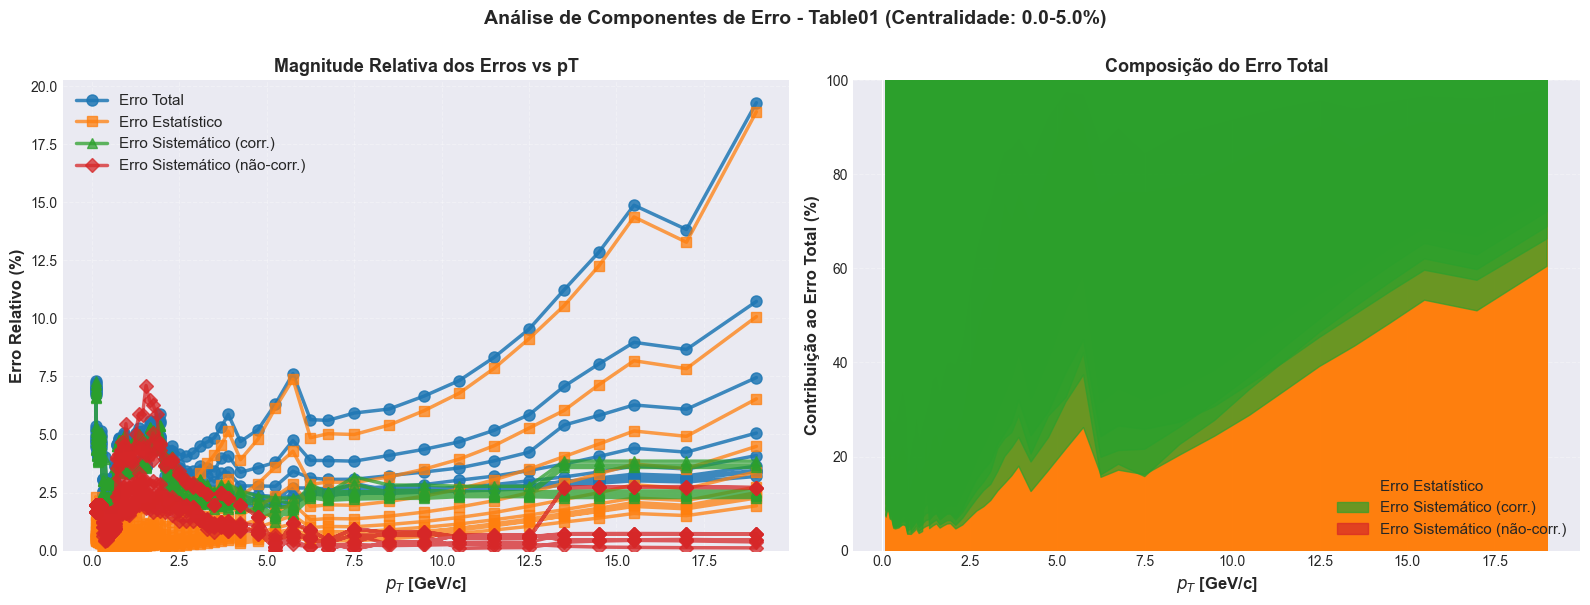

✓ Gráfico de análise de erros salvo em: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots/Table01_centrality_0-5_error_analysis.png


In [20]:
# Calcular erros relativos (em %)
error_total_rel = (error_total_plus / df[value_col] * 100)
error_stat_rel = (np.abs(df[stat_plus_col]) / df[value_col] * 100)
error_syst_rel = (np.abs(df[syst_plus_col]) / df[value_col] * 100)
error_syst_uncorr_rel = (np.abs(df[syst_uncorr_plus_col]) / df[value_col] * 100)

# Converter para numpy arrays
error_total_rel = error_total_rel.values
error_stat_rel = error_stat_rel.values
error_syst_rel = error_syst_rel.values
error_syst_uncorr_rel = error_syst_uncorr_rel.values

# Criar figura de comparação de erros relativos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Erros absolutos
ax1.plot(df[pt_col], error_total_rel, 'o-', linewidth=2.5, markersize=8,
         label='Erro Total', color='#1f77b4', alpha=0.85)
ax1.plot(df[pt_col], error_stat_rel, 's-', linewidth=2.5, markersize=7,
         label='Erro Estatístico', color='#ff7f0e', alpha=0.75)
ax1.plot(df[pt_col], error_syst_rel, '^-', linewidth=2.5, markersize=7,
         label='Erro Sistemático (corr.)', color='#2ca02c', alpha=0.75)
ax1.plot(df[pt_col], error_syst_uncorr_rel, 'D-', linewidth=2.5, markersize=7,
         label='Erro Sistemático (não-corr.)', color='#d62728', alpha=0.75)

ax1.set_xlabel(r"$p_T$ [GeV/c]", fontsize=12, fontweight='bold')
ax1.set_ylabel("Erro Relativo (%)", fontsize=12, fontweight='bold')
ax1.set_title("Magnitude Relativa dos Erros vs pT", fontsize=13, fontweight='bold')
ax1.grid(True, which='both', alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='best', framealpha=0.95)
ax1.set_ylim(bottom=0)

# Gráfico 2: Contribuição percentual de cada erro ao erro total
# Evitar divisão por zero
with np.errstate(divide='ignore', invalid='ignore'):
    error_stat_contrib = np.where(error_total_rel > 0, error_stat_rel / error_total_rel * 100, 0)
    error_syst_contrib = np.where(error_total_rel > 0, error_syst_rel / error_total_rel * 100, 0)
    error_syst_uncorr_contrib = np.where(error_total_rel > 0, error_syst_uncorr_rel / error_total_rel * 100, 0)

ax2.fill_between(df[pt_col], 0, error_stat_contrib, alpha=0.7, label='Erro Estatístico', color='#ff7f0e')
ax2.fill_between(df[pt_col], error_stat_contrib, error_stat_contrib + error_syst_contrib,
                  alpha=0.7, label='Erro Sistemático (corr.)', color='#2ca02c')
ax2.fill_between(df[pt_col], error_stat_contrib + error_syst_contrib,
                  error_stat_contrib + error_syst_contrib + error_syst_uncorr_contrib,
                  alpha=0.7, label='Erro Sistemático (não-corr.)', color='#d62728')

ax2.set_xlabel(r"$p_T$ [GeV/c]", fontsize=12, fontweight='bold')
ax2.set_ylabel("Contribuição ao Erro Total (%)", fontsize=12, fontweight='bold')
ax2.set_title("Composição do Erro Total", fontsize=13, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=11, loc='best', framealpha=0.95)
ax2.grid(True, which='both', alpha=0.3, linestyle='--', axis='y')

fig.suptitle(f"Análise de Componentes de Erro - Table01 (Centralidade: {centrality_str}%)",
             fontsize=14, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Table01_centrality_0-5_error_analysis.png", dpi=DPI, bbox_inches='tight')
plt.show()

print(f"✓ Gráfico de análise de erros salvo em: {OUTPUT_DIR / 'Table01_centrality_0-5_error_analysis.png'}")

## 6. Resumo Final e Arquivos Gerados

In [21]:
print("\n" + "=" * 100)
print("RESUMO FINAL - ANÁLISE TABLE01")
print("=" * 100)

# Listar todos os arquivos gerados
output_files = list(OUTPUT_DIR.glob("*"))
output_files.sort()

print(f"\nArquivos gerados no diretório: {OUTPUT_DIR}\n")
total_size = 0
for i, file in enumerate(output_files, 1):
    size_kb = file.stat().st_size / 1024
    total_size += file.stat().st_size
    print(f"  {i}. {file.name:50s} ({size_kb:8.1f} KB)")

print(f"\n  Tamanho total: {total_size / (1024*1024):.2f} MB")

print("\n" + "=" * 100)
print("INFORMAÇÕES TÉCNICAS DO ARQUIVO")
print("=" * 100)
print(f"  Total de pontos de medida: {len(df)}")
print(f"  Intervalo de pT: [{df[pt_col].min():.4f}, {df[pt_col].max():.4f}] GeV/c")
print(f"  Intervalo de valores: [{df[value_col].min():.2f}, {df[value_col].max():.2f}]")
print(f"  Centralidade: {centrality_str}%")
print(f"  Rapididade (Y): {metadata.get('rapidity', 'N/A')}")
print(f"  Energia do feixe (√s_NN): {metadata.get('energy', 'N/A')} GeV")
print(f"  Reação: {metadata.get('reactions', 'N/A')}")
print(f"  Observável: {metadata.get('observables', 'N/A')}")

print("\n" + "=" * 100)
print("✓ ANÁLISE COMPLETA - Table01 (Centralidade 0-5%)")
print("=" * 100 + "\n")


RESUMO FINAL - ANÁLISE TABLE01

Arquivos gerados no diretório: /Users/avilamrs/Library/Mobile Documents/com~apple~CloudDocs/Repository/Academia/Research/High-Energy-Physics-Research/Gaussian-Process-Research/Table01-plots

  1. Table01_centrality_0-5_data.csv                    (    44.3 KB)
  2. Table01_centrality_0-5_error_analysis.png          (   840.6 KB)
  3. Table01_centrality_0-5_error_decomposition.png     (  1419.4 KB)
  4. Table01_centrality_0-5_main.png                    (   928.1 KB)

  Tamanho total: 3.16 MB

INFORMAÇÕES TÉCNICAS DO ARQUIVO
  Total de pontos de medida: 625
  Intervalo de pT: [0.1100, 19.0000] GeV/c
  Intervalo de valores: [0.00, 5020.00]
  Centralidade: 0.0-5.0%
  Rapididade (Y): -0.5-0.5
  Energia do feixe (√s_NN): N/A GeV
  Reação: PB PB --> PI+ X | PB PB --> PI- X
  Observável: DN/DPT

✓ ANÁLISE COMPLETA - Table01 (Centralidade 0-5%)

